In [1]:
import pandas as pd 
import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import utils 
pd.options.display.float_format = '{:.1f}'.format



In [2]:
df_cpu = pd.read_csv("result_cpu.csv")

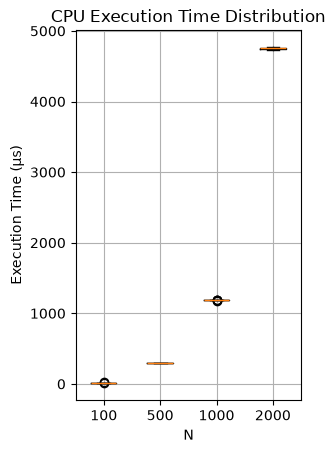

In [3]:
N_values = [100, 500, 1000, 2000]

# CPU
plt.subplot(1, 2, 1)

plt.boxplot(
    [df_cpu[df_cpu['N'] == n]['time_us'] for n in N_values],
    tick_labels=N_values
)

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("CPU Execution Time Distribution")
plt.grid(True)


In [4]:
groupby = "N"
var_to_compute = "time_us" 
clean_data_cpu = utils.remove_outliers(df_cpu , groupby , var_to_compute )
n_cpu = len(clean_data_cpu)
removed_percentages_cpu = 0 if len(df_cpu) == 0 else ( (len(df_cpu) - n_cpu) / len(df_cpu) ) * 100


In [5]:

print("CPU VERSION : ")
print(f"Original Samples : {len(df_cpu)}" )
print(f"Clean Samples : {n_cpu}")
print(f"Removed         : {removed_percentages_cpu:.2f} %")


CPU VERSION : 
Original Samples : 80
Clean Samples : 74
Removed         : 7.50 %


In [6]:
original_count = df_cpu.groupby('N').size()
clean_count = clean_data_cpu.groupby('N').size()

outlier_stats = pd.DataFrame({
    'original': original_count,
    'clean': clean_count
})

outlier_stats['removed'] = (
    outlier_stats['original'] -
    outlier_stats['clean']
)

outlier_stats['removed_%'] = (
    outlier_stats['removed'] /
    outlier_stats['original'] * 100
)

outlier_stats


,original,clean,removed,removed_%
N,,,,
100,20,18,2,10.0
500,20,20,0,0.0
1000,20,16,4,20.0
2000,20,20,0,0.0


In [10]:
groupby = "N"
var_to_compute = "time_us" 
stats_data =  utils.stats( clean_data_cpu , groupby, var_to_compute)
stats_data = stats_data.reset_index()
stats_data

,N,count,min,max,median,mean,std,cv,cv_%
0,100,18,11,11,11.0,11.0,0.0,0.0,0.0
1,500,20,294,299,296.0,296.2,1.4,0.0,0.5
2,1000,16,1182,1190,1187.0,1186.4,2.4,0.0,0.2
3,2000,20,4729,4770,4752.0,4749.6,11.8,0.0,0.2


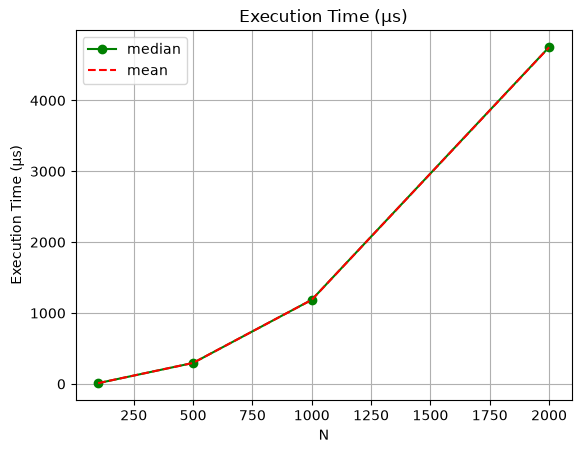

In [8]:
# median_execution_time():

plt.plot(stats_data['N'], stats_data['median'], color='green', marker='o', label='median')
plt.plot(stats_data['N'], stats_data['mean'], color='red', linestyle='--', label='mean')

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time (µs)")
plt.grid(True)
plt.legend() 
plt.show()

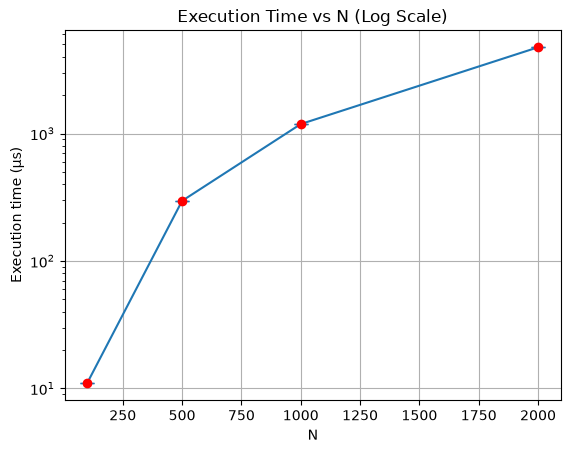

In [9]:
# execution_time_log():
plt.errorbar(
    stats_data['N'],
    stats_data['mean'],
    yerr=stats_data['std'],
    fmt='-',
    capsize=5
)

plt.scatter(
    stats_data['N'],
    stats_data['mean'],
    color='red',
    zorder=3
)

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Execution time (µs)")
plt.title("Execution Time vs N (Log Scale)")
plt.grid(True)

plt.show()